Old Models

Loading test data...
Preparing test data...

Loading saved models...
Loaded SVM
Loaded Logistic Regression
Loaded Naive Bayes
Loaded XGBoost
Loaded Random Forest (wrapped in dictionary)
Loaded Ensemble

Loading feature transformers...
Loaded vectorizer
Loaded minmax_scaler
Loaded standard_scaler
Loaded label_encoder

Creating vectorizer with training configuration...
Fitting vectorizer on training data...

Evaluating models...

Evaluating SVM...
Accuracy: 0.2936

Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.21      0.27      0.24      7136
          General Business Communication       0.32      0.31      0.31     11185
        IT Alerts & System Notifications       0.37      0.35      0.36      4000
          Internal Policies & HR Updates       0.33      0.32      0.32      4000
                     Legal & Contractual       0.34      0.38      0.36      4000
                

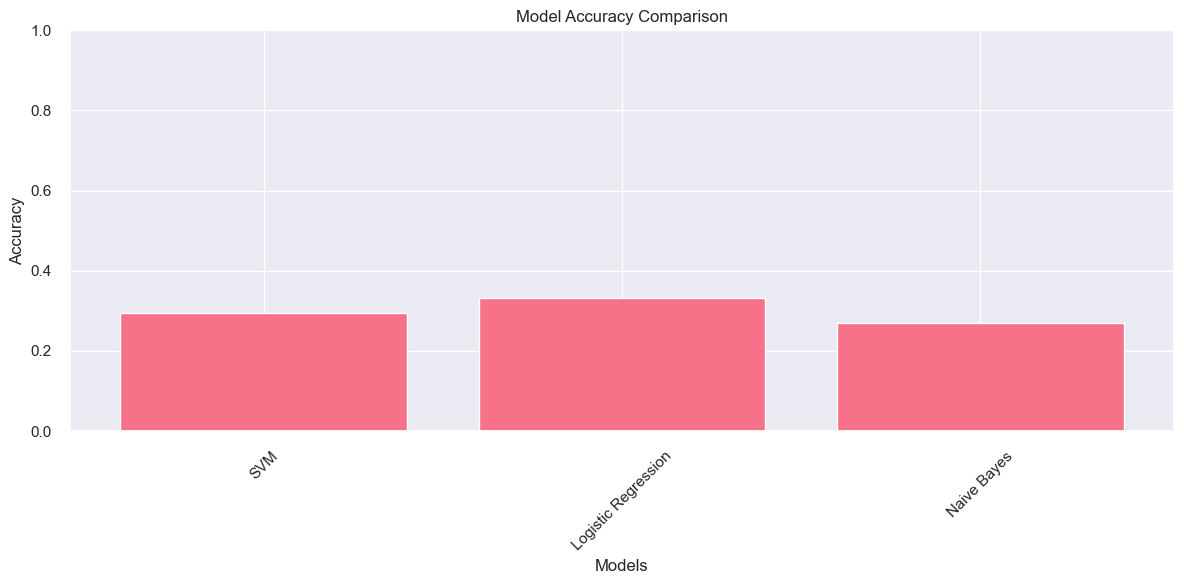

<Figure size 1200x600 with 0 Axes>

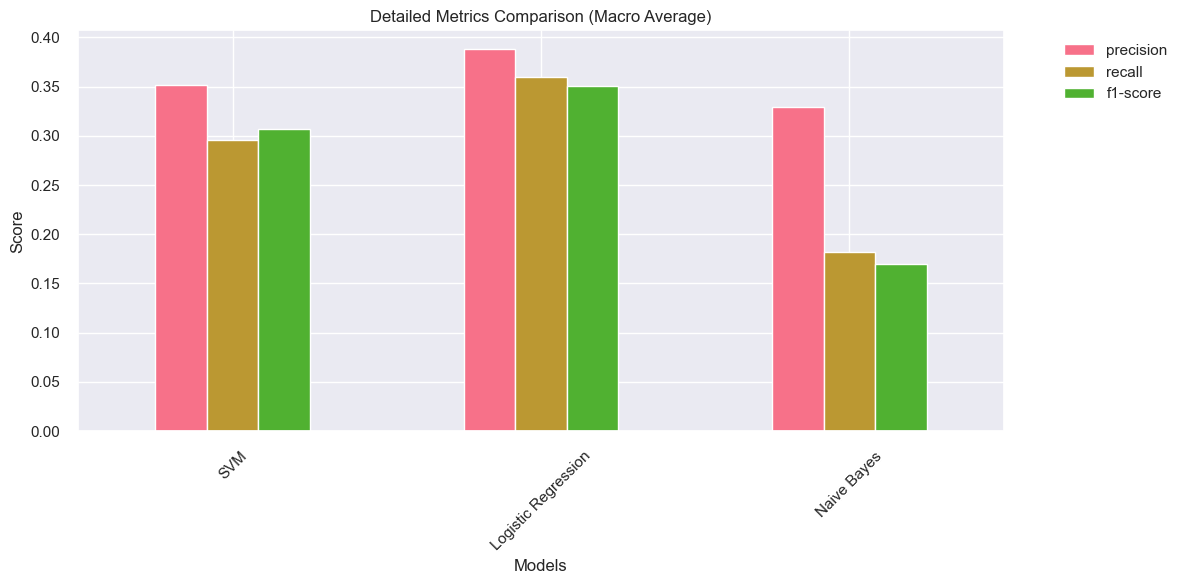

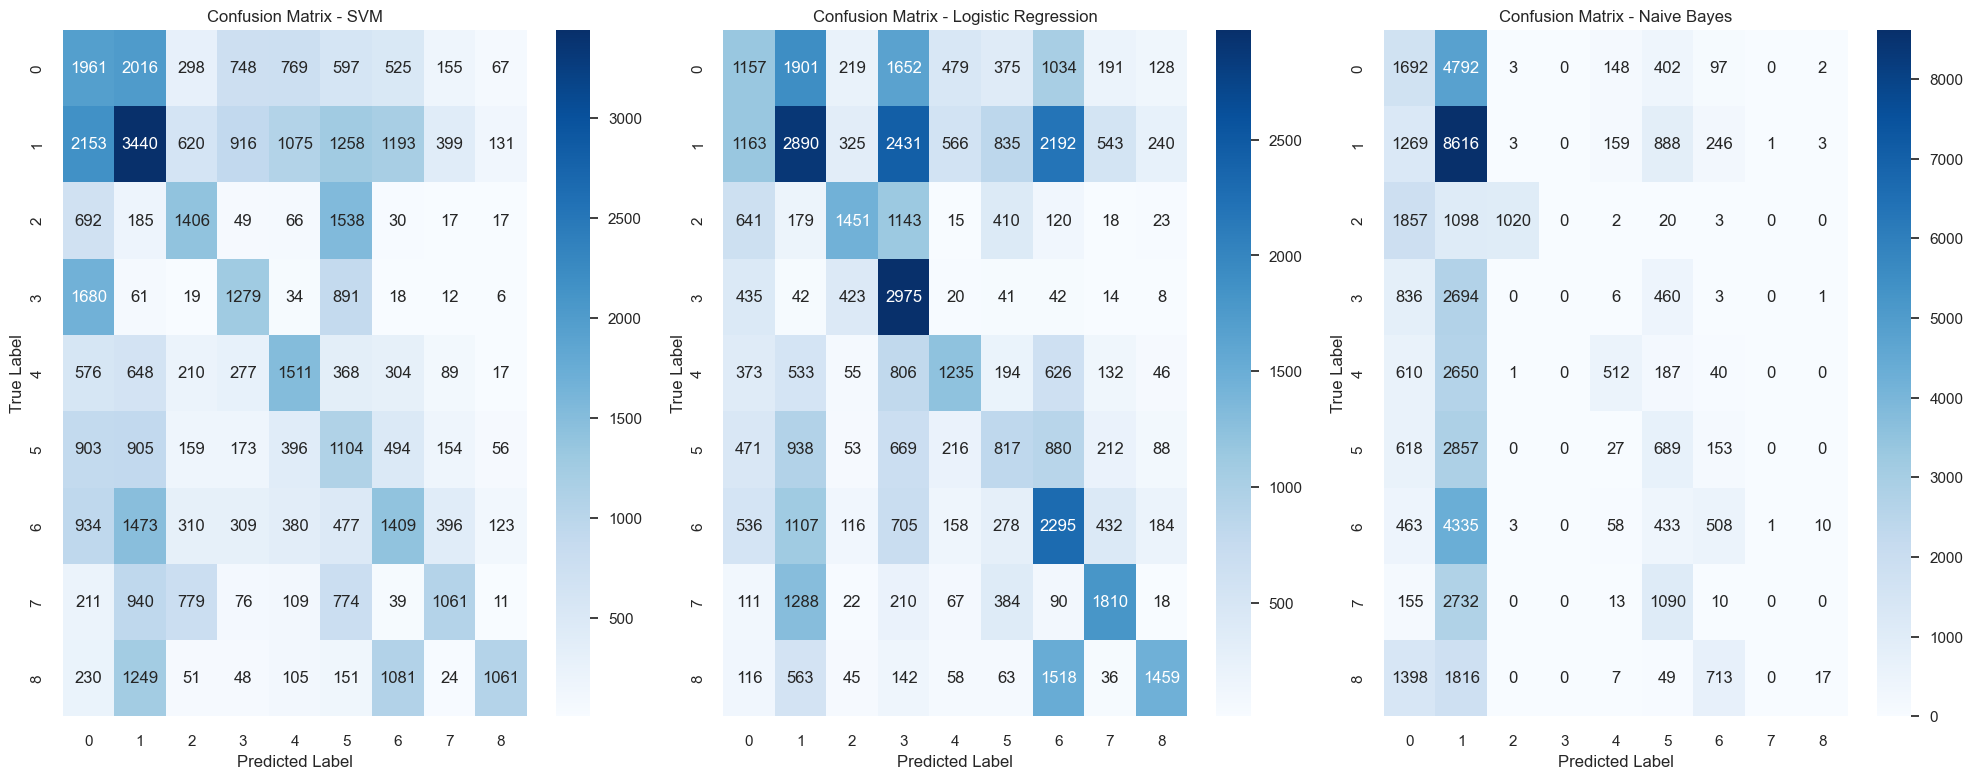

<Figure size 1500x800 with 0 Axes>

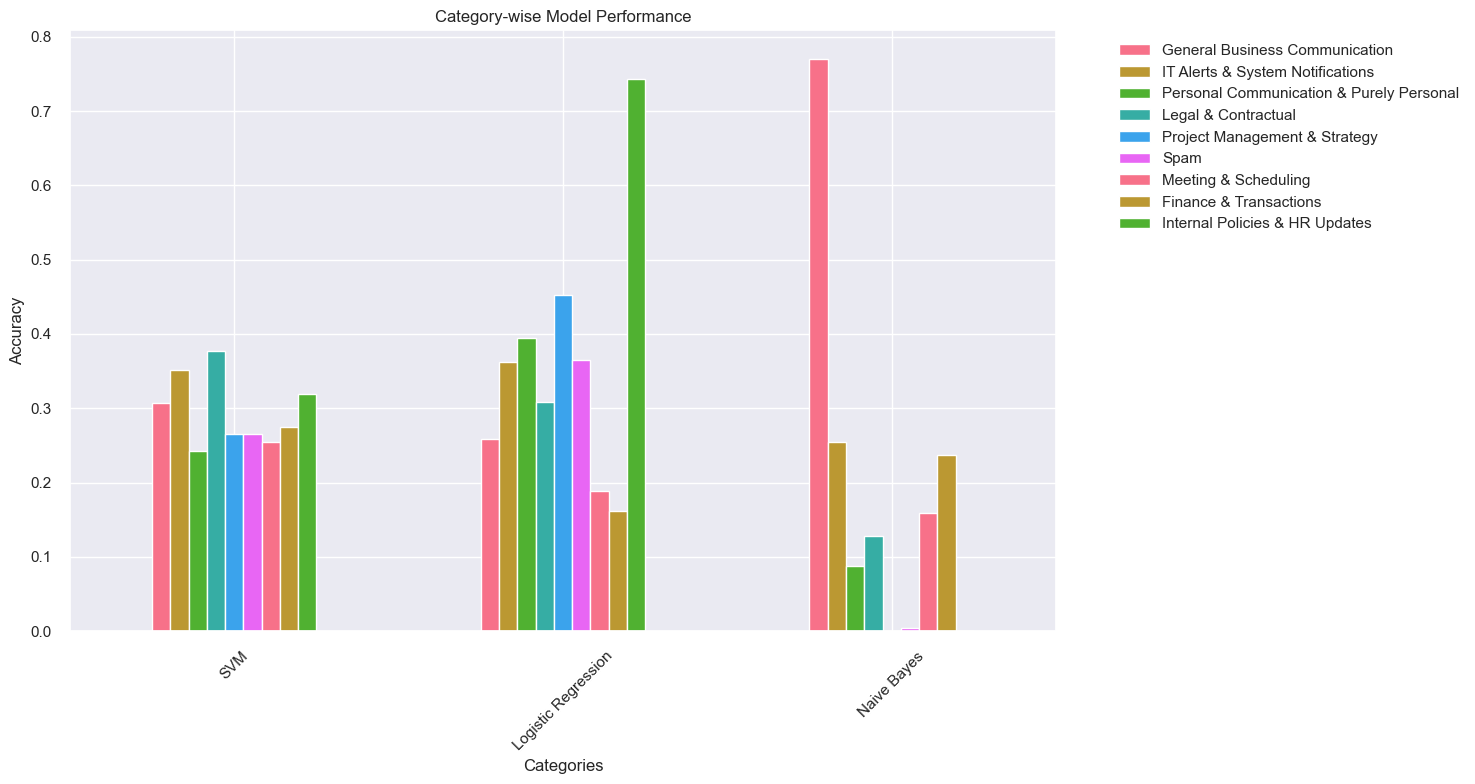


Model Performance Summary:
                 Model  Accuracy  Macro Precision  Macro Recall  \
0                  SVM    0.2936           0.3515        0.2954   
1  Logistic Regression    0.3319           0.3877        0.3596   
2          Naive Bayes    0.2693           0.3297        0.1823   

   Macro F1-Score  
0          0.3071  
1          0.3507  
2          0.1700  


In [11]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
import re
import warnings
import os
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_theme()
sns.set_palette('husl')

# Text cleaning function
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

# Load test data
print("Loading test data...")
email_data = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/FYP PART 2/Category Modeling/final_email_category_balanced.csv')

# Prepare test data
print("Preparing test data...")
email_data['cleaned_subject'] = email_data['Cleaned_Subject'].apply(clean_text)
email_data['cleaned_message'] = email_data['Cleaned_Message'].apply(clean_text)
email_data['combined_text'] = email_data['cleaned_subject'] + ' SUBJECT_END ' + email_data['cleaned_message']

# Split data
from sklearn.model_selection import train_test_split
X = email_data['combined_text']
y = email_data['Qwen2.5_Category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define base path
base_path = 'C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/FYP PART 2/Category Modeling/Old Category Models/Bad Models 20%'

# Load all saved models
print("\nLoading saved models...")
models = {}

# Load individual models
model_files = {
    'SVM': 'svm_category_model.joblib',
    'Logistic Regression': 'lr_category_model.joblib',
    'Naive Bayes': 'nb_category_model.joblib',
    'XGBoost': 'xgb_category_model.joblib',
    'Random Forest': 'rf_category_model.joblib',
    'Ensemble': 'ensemble_category_model.joblib'
}

for name, file in model_files.items():
    try:
        model_path = os.path.join(base_path, file)
        model_data = joblib.load(model_path)
        # Check if model_data is a dictionary with 'model' key
        if isinstance(model_data, dict) and 'model' in model_data:
            models[name] = model_data
            print(f"Loaded {name}")
        else:
            # If it's just the model, wrap it in a dictionary
            models[name] = {'model': model_data}
            print(f"Loaded {name} (wrapped in dictionary)")
    except Exception as e:
        print(f"Error loading {name}: {str(e)}")

# Load feature transformers
print("\nLoading feature transformers...")
transformers = {}
transformer_files = {
    'vectorizer': 'tfidf_vectorizer.joblib',
    'minmax_scaler': 'minmax_scaler.joblib',
    'standard_scaler': 'standard_scaler.joblib',
    'label_encoder': 'label_encoder.joblib'
}

for name, file in transformer_files.items():
    try:
        transformer_path = os.path.join(base_path, file)
        transformers[name] = joblib.load(transformer_path)
        print(f"Loaded {name}")
    except Exception as e:
        print(f"Error loading {name}: {str(e)}")

# Create a new vectorizer with the same configuration as used in training
print("\nCreating vectorizer with training configuration...")
training_vectorizer = TfidfVectorizer(
    max_features=2017,  # Match the expected number of features
    ngram_range=(1, 3),
    stop_words='english'
)

# Fit the vectorizer on the training data
print("Fitting vectorizer on training data...")
training_vectorizer.fit(X_train)

# Evaluate each model
print("\nEvaluating models...")
results = {}

for name, model_data in models.items():
    print(f"\nEvaluating {name}...")
    
    try:
        # Get the model
        model = model_data['model']
        
        # Transform test data using the training vectorizer
        X_test_transformed = training_vectorizer.transform(X_test)
        
        # Make predictions
        if name == 'Ensemble':
            # For ensemble model, use predict instead of predict_proba
            y_pred = model.predict(X_test_transformed)
        else:
            y_pred = model.predict(X_test_transformed)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)
        
        # Store results
        results[name] = {
            'accuracy': accuracy,
            'report': report,
            'predictions': y_pred
        }
        
        # Print results
        print(f"Accuracy: {accuracy:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
    except Exception as e:
        print(f"Error evaluating {name}: {str(e)}")
        continue

# Only proceed with visualizations if we have results
if results:
    # Visualize model comparison
    print("\nCreating visualizations...")

    # 1. Accuracy Comparison
    plt.figure(figsize=(12, 6))
    accuracies = [results[name]['accuracy'] for name in results.keys()]
    plt.bar(results.keys(), accuracies)
    plt.title('Model Accuracy Comparison')
    plt.xlabel('Models')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    # 2. Detailed Metrics Comparison
    metrics = ['precision', 'recall', 'f1-score']
    macro_metrics = {}

    for name in results.keys():
        macro_metrics[name] = {
            metric: float(results[name]['report']['macro avg'][metric])
            for metric in metrics
        }

    metrics_df = pd.DataFrame(macro_metrics).T
    metrics_df = metrics_df.astype(float)  # Ensure all values are numeric

    plt.figure(figsize=(12, 6))
    metrics_df.plot(kind='bar', figsize=(12, 6))
    plt.title('Detailed Metrics Comparison (Macro Average)')
    plt.xlabel('Models')
    plt.ylabel('Score')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 3. Confusion Matrices
    plt.figure(figsize=(20, 15))
    for i, (name, result) in enumerate(results.items(), 1):
        plt.subplot(2, 3, i)
        cm = confusion_matrix(y_test, result['predictions'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - {name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    # 4. Category-wise Performance
    categories = y_test.unique()
    category_metrics = {}

    for category in categories:
        category_metrics[category] = {}
        for name in results.keys():
            category_indices = y_test == category
            y_pred_category = results[name]['predictions'][category_indices]
            y_true_category = y_test[category_indices]
            
            if len(y_true_category) > 0:
                accuracy = accuracy_score(y_true_category, y_pred_category)
                category_metrics[category][name] = accuracy

    category_df = pd.DataFrame(category_metrics)
    category_df = category_df.astype(float)  # Ensure all values are numeric
    plt.figure(figsize=(15, 8))
    category_df.plot(kind='bar', figsize=(15, 8))
    plt.title('Category-wise Model Performance')
    plt.xlabel('Categories')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Print summary table
    print("\nModel Performance Summary:")
    summary_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [results[name]['accuracy'] for name in results.keys()],
        'Macro Precision': [float(results[name]['report']['macro avg']['precision']) for name in results.keys()],
        'Macro Recall': [float(results[name]['report']['macro avg']['recall']) for name in results.keys()],
        'Macro F1-Score': [float(results[name]['report']['macro avg']['f1-score']) for name in results.keys()]
    })

    print(summary_df.round(4))
else:
    print("\nNo models were successfully loaded and evaluated. Please check the model files and paths.")

Old Model 2

Loading test data...
Preparing test data...

Loading saved models...
Loaded Logistic Regression (wrapped in dictionary)
Loaded Naive Bayes (wrapped in dictionary)
Loaded Random Forest (wrapped in dictionary)
Loaded XGBoost (wrapped in dictionary)

Loading feature transformers...
Loaded vectorizer
Loaded minmax_scaler
Loaded standard_scaler
Loaded label_encoder

Creating vectorizer with training configuration...
Fitting vectorizer on training data...
Encoding labels...

Evaluating models...

Evaluating Logistic Regression...
Accuracy: 0.0825

Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.00      0.00      0.00      7136
          General Business Communication       0.00      0.00      0.00     11185
        IT Alerts & System Notifications       0.00      0.00      0.00      4000
          Internal Policies & HR Updates       0.00      0.00      0.00      4000
                  

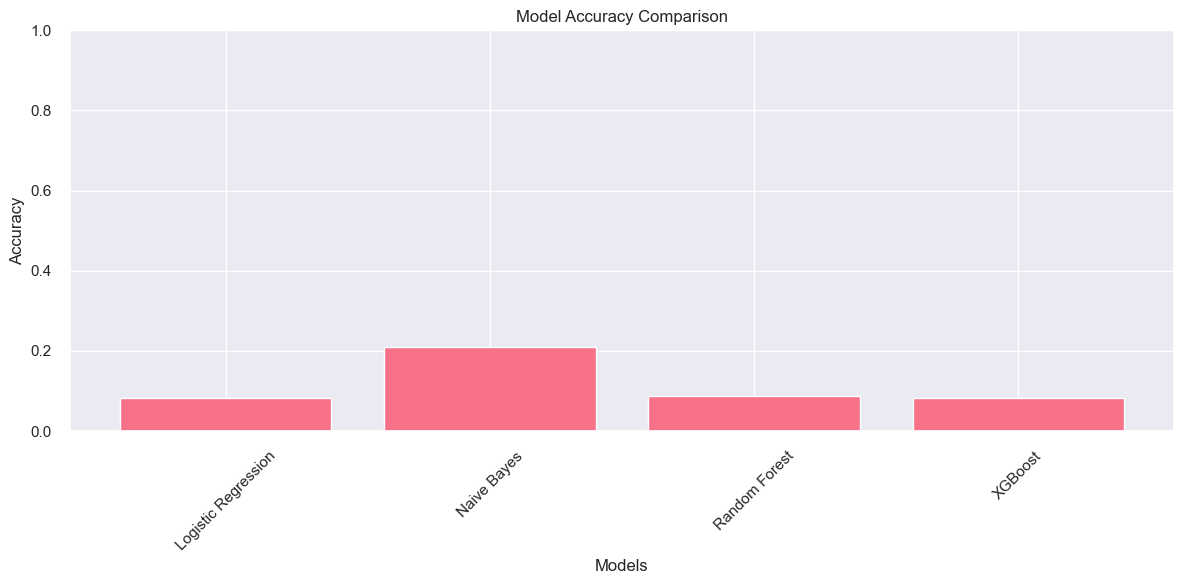

<Figure size 1200x600 with 0 Axes>

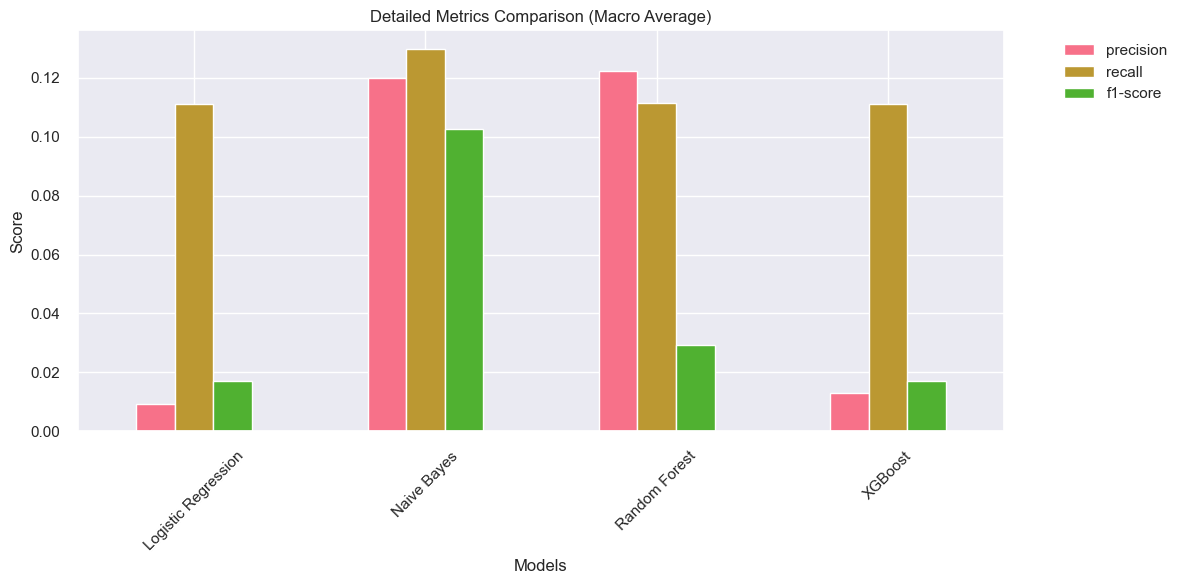

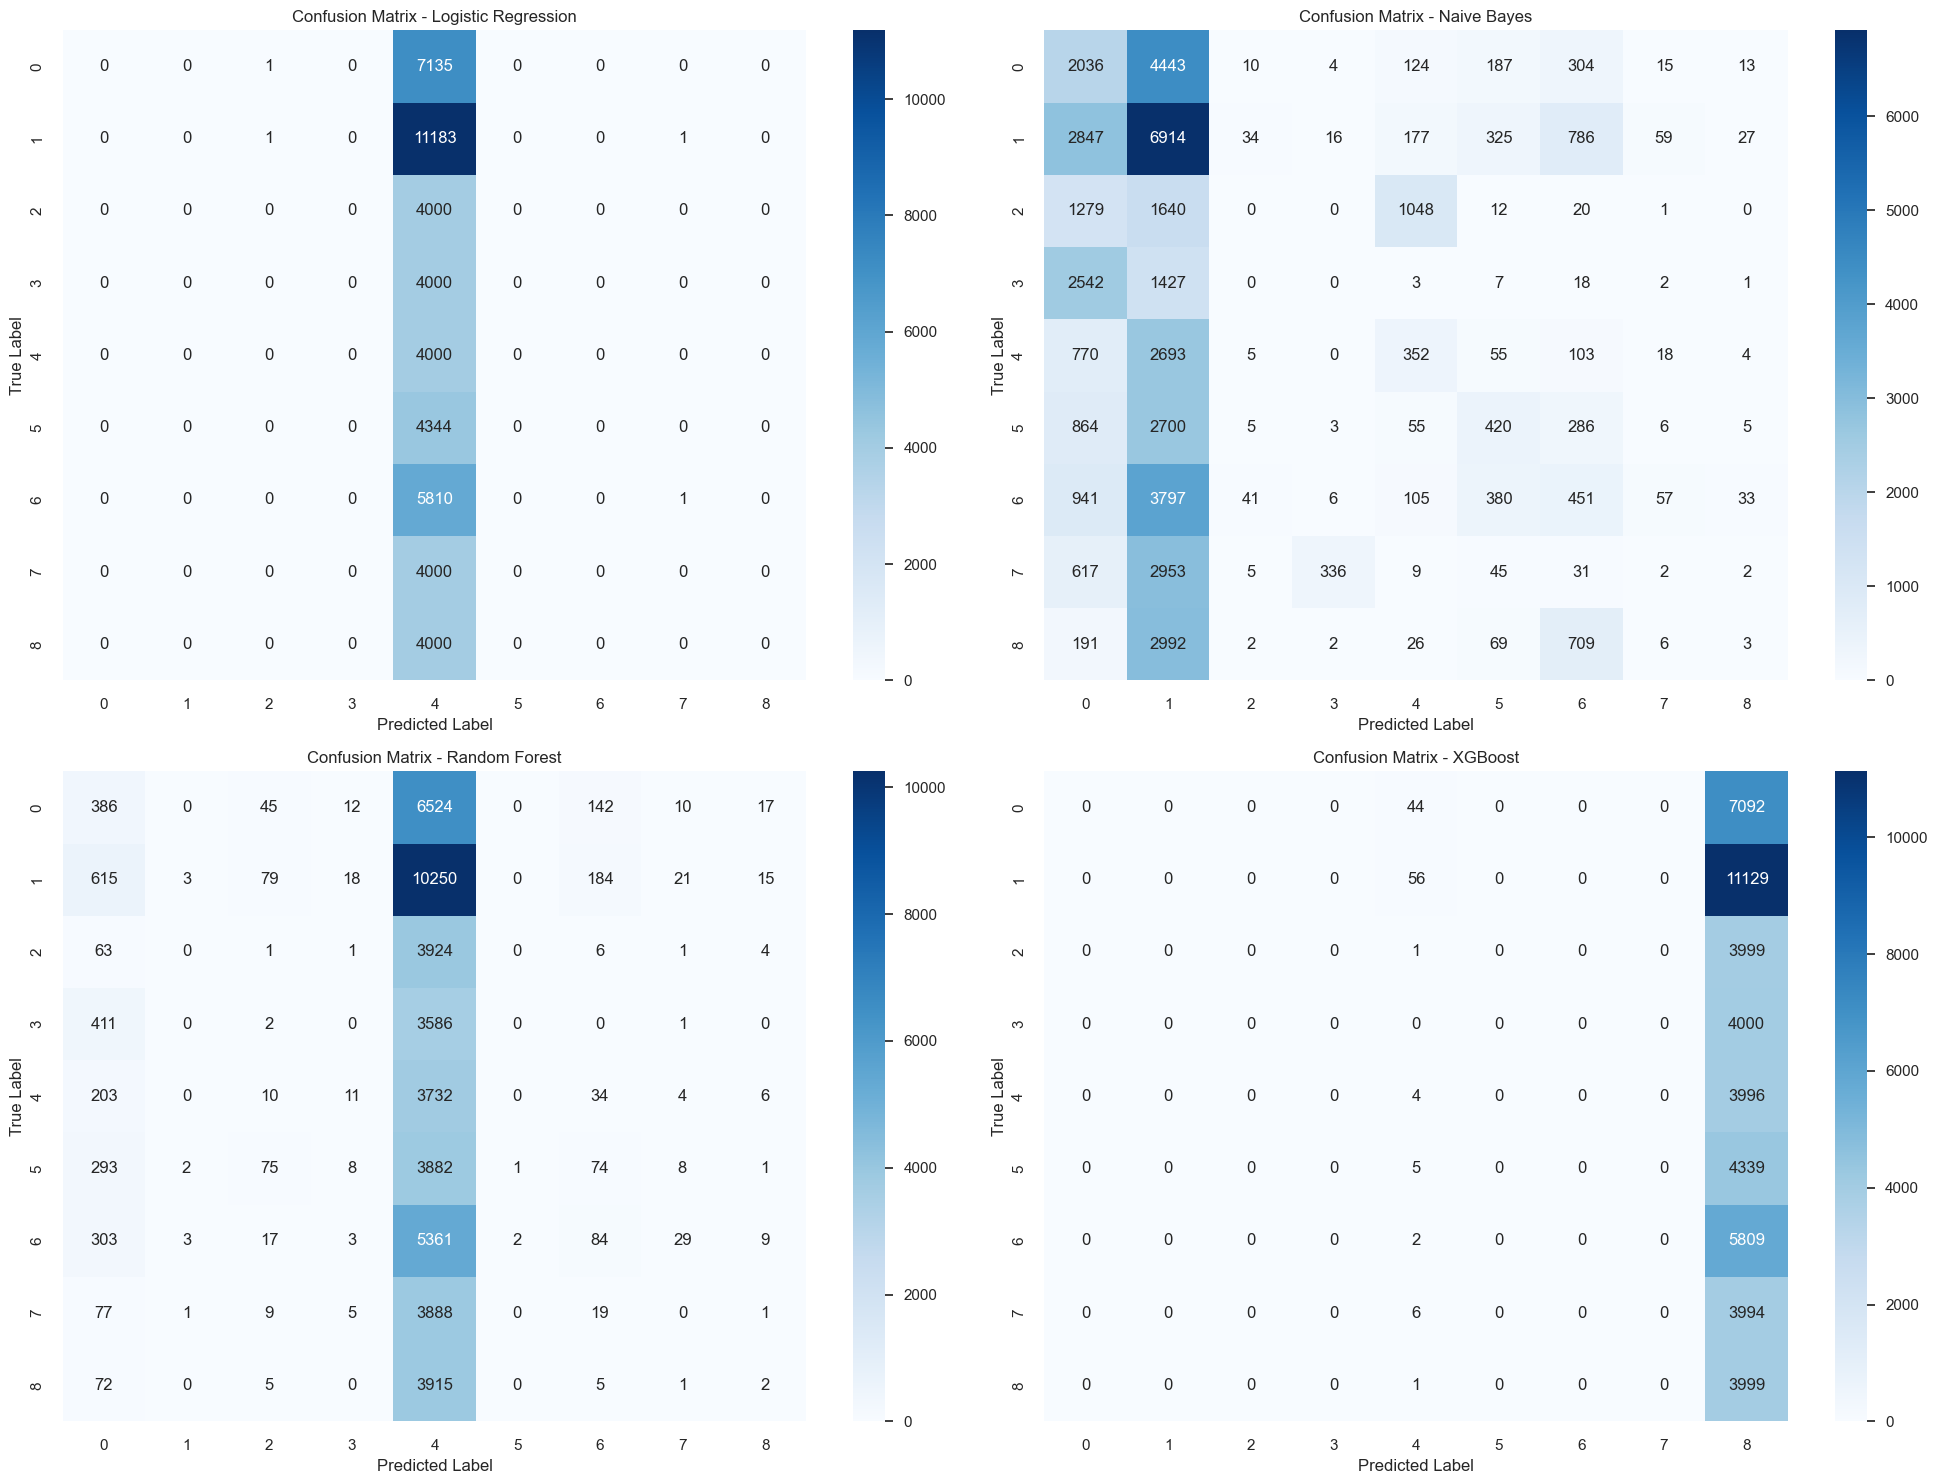

<Figure size 1500x800 with 0 Axes>

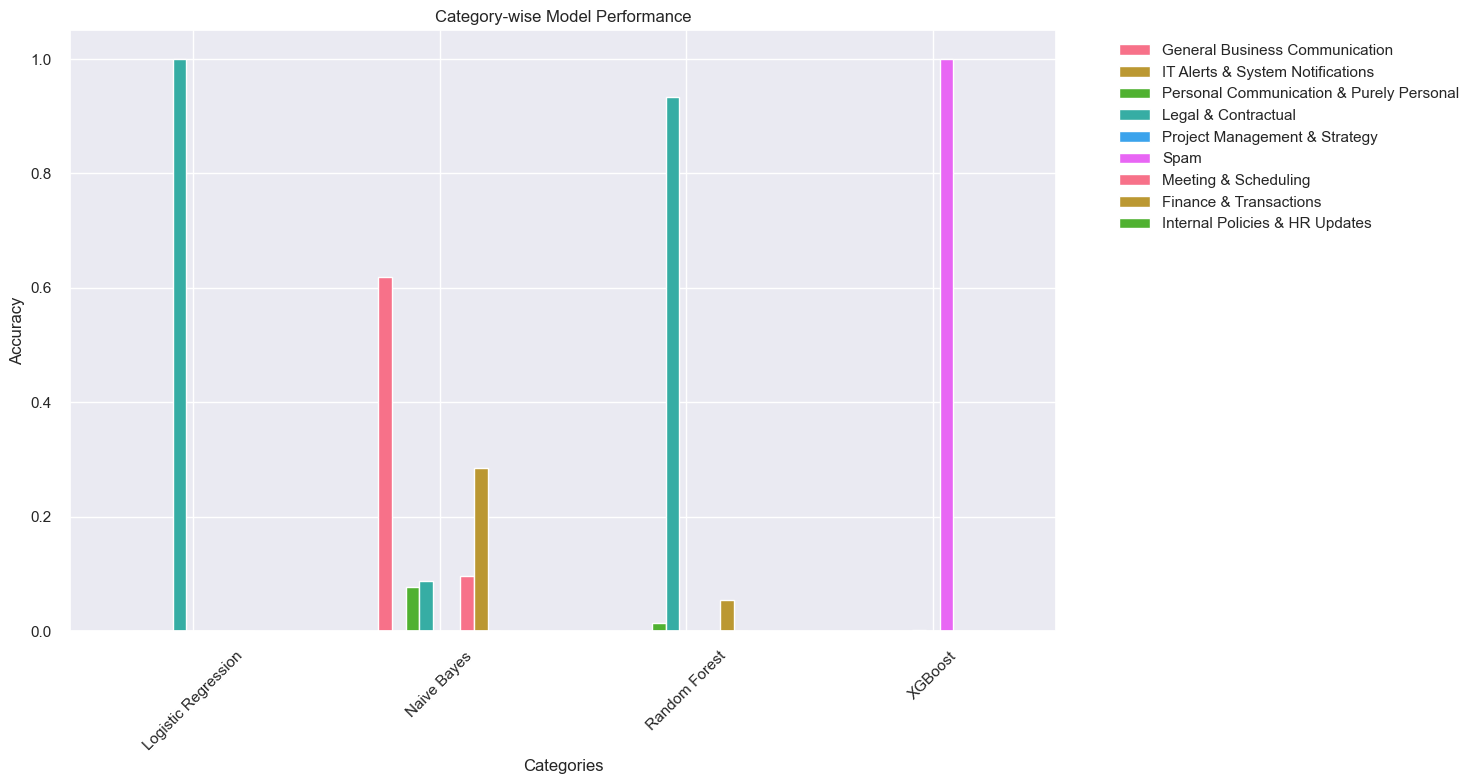


Model Performance Summary:
                 Model  Accuracy  Macro Precision  Macro Recall  \
0  Logistic Regression    0.0825           0.0092        0.1111   
1          Naive Bayes    0.2100           0.1200        0.1297   
2        Random Forest    0.0868           0.1225        0.1114   
3              XGBoost    0.0826           0.0129        0.1112   

   Macro F1-Score  
0          0.0169  
1          0.1025  
2          0.0291  
3          0.0172  


In [15]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
import re
import warnings
import os
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_theme()
sns.set_palette('husl')

# Text cleaning function
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

# Load test data
print("Loading test data...")
email_data = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/FYP PART 2/Category Modeling/final_email_category_balanced.csv')

# Prepare test data
print("Preparing test data...")
email_data['cleaned_subject'] = email_data['Cleaned_Subject'].apply(clean_text)
email_data['cleaned_message'] = email_data['Cleaned_Message'].apply(clean_text)
email_data['combined_text'] = email_data['cleaned_subject'] + ' SUBJECT_END ' + email_data['cleaned_message']

# Split data
from sklearn.model_selection import train_test_split
X = email_data['combined_text']
y = email_data['Qwen2.5_Category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define base path
base_path = 'C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/FYP PART 2/Category Modeling/Old Category Models/Current Models'

# Load all saved models
print("\nLoading saved models...")
models = {}

# Load specific models for comparison
model_files = {
    'Logistic Regression': 'logistic_regression_category_model.joblib',
    'Naive Bayes': 'naive_bayes_category_model.joblib',
    'Random Forest': 'random_forest_category_model.joblib',
    'XGBoost': 'xgboost_category_model.joblib'
}

for name, file in model_files.items():
    try:
        model_path = os.path.join(base_path, file)
        model_data = joblib.load(model_path)
        # Check if model_data is a dictionary with 'model' key
        if isinstance(model_data, dict) and 'model' in model_data:
            models[name] = model_data
            print(f"Loaded {name}")
        else:
            # If it's just the model, wrap it in a dictionary
            models[name] = {'model': model_data}
            print(f"Loaded {name} (wrapped in dictionary)")
    except Exception as e:
        print(f"Error loading {name}: {str(e)}")

# Load feature transformers
print("\nLoading feature transformers...")
transformers = {}
transformer_files = {
    'vectorizer': 'tfidf_vectorizer.joblib',
    'minmax_scaler': 'minmax_scaler.joblib',
    'standard_scaler': 'standard_scaler.joblib',
    'label_encoder': 'label_encoder.joblib'
}

for name, file in transformer_files.items():
    try:
        transformer_path = os.path.join(base_path, file)
        transformers[name] = joblib.load(transformer_path)
        print(f"Loaded {name}")
    except Exception as e:
        print(f"Error loading {name}: {str(e)}")

# Create a new vectorizer with the same configuration as used in training
print("\nCreating vectorizer with training configuration...")
training_vectorizer = TfidfVectorizer(
    max_features=5002,  # Updated to match the expected number of features
    ngram_range=(1, 3),
    stop_words='english'
)

# Fit the vectorizer on the training data
print("Fitting vectorizer on training data...")
training_vectorizer.fit(X_train)

# Encode labels using the loaded label encoder
print("Encoding labels...")
label_encoder = transformers['label_encoder']
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Evaluate each model
print("\nEvaluating models...")
results = {}

for name, model_data in models.items():
    print(f"\nEvaluating {name}...")
    
    try:
        # Get the model
        model = model_data['model']
        
        # Transform test data using the training vectorizer
        X_test_transformed = training_vectorizer.transform(X_test)
        
        # Make predictions
        y_pred_encoded = model.predict(X_test_transformed)
        
        # Convert predictions back to original labels
        y_pred = label_encoder.inverse_transform(y_pred_encoded)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)
        
        # Store results
        results[name] = {
            'accuracy': accuracy,
            'report': report,
            'predictions': y_pred
        }
        
        # Print results
        print(f"Accuracy: {accuracy:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
    except Exception as e:
        print(f"Error evaluating {name}: {str(e)}")
        continue

# Only proceed with visualizations if we have results
if results:
    # Visualize model comparison
    print("\nCreating visualizations...")

    # 1. Accuracy Comparison
    plt.figure(figsize=(12, 6))
    accuracies = [results[name]['accuracy'] for name in results.keys()]
    plt.bar(results.keys(), accuracies)
    plt.title('Model Accuracy Comparison')
    plt.xlabel('Models')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    # 2. Detailed Metrics Comparison
    metrics = ['precision', 'recall', 'f1-score']
    macro_metrics = {}

    for name in results.keys():
        macro_metrics[name] = {
            metric: float(results[name]['report']['macro avg'][metric])
            for metric in metrics
        }

    metrics_df = pd.DataFrame(macro_metrics).T
    metrics_df = metrics_df.astype(float)  # Ensure all values are numeric

    plt.figure(figsize=(12, 6))
    metrics_df.plot(kind='bar', figsize=(12, 6))
    plt.title('Detailed Metrics Comparison (Macro Average)')
    plt.xlabel('Models')
    plt.ylabel('Score')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 3. Confusion Matrices
    plt.figure(figsize=(20, 15))
    for i, (name, result) in enumerate(results.items(), 1):
        plt.subplot(2, 2, i)  # Changed to 2x2 grid for 4 models
        cm = confusion_matrix(y_test, result['predictions'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - {name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    # 4. Category-wise Performance
    categories = y_test.unique()
    category_metrics = {}

    for category in categories:
        category_metrics[category] = {}
        for name in results.keys():
            category_indices = y_test == category
            y_pred_category = results[name]['predictions'][category_indices]
            y_true_category = y_test[category_indices]
            
            if len(y_true_category) > 0:
                accuracy = accuracy_score(y_true_category, y_pred_category)
                category_metrics[category][name] = accuracy

    category_df = pd.DataFrame(category_metrics)
    category_df = category_df.astype(float)  # Ensure all values are numeric
    plt.figure(figsize=(15, 8))
    category_df.plot(kind='bar', figsize=(15, 8))
    plt.title('Category-wise Model Performance')
    plt.xlabel('Categories')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Print summary table
    print("\nModel Performance Summary:")
    summary_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [results[name]['accuracy'] for name in results.keys()],
        'Macro Precision': [float(results[name]['report']['macro avg']['precision']) for name in results.keys()],
        'Macro Recall': [float(results[name]['report']['macro avg']['recall']) for name in results.keys()],
        'Macro F1-Score': [float(results[name]['report']['macro avg']['f1-score']) for name in results.keys()]
    })

    print(summary_df.round(4))
else:
    print("\nNo models were successfully loaded and evaluated. Please check the model files and paths.")